<a href="https://colab.research.google.com/github/cabreonictor/Modelado-de-IA-Aplicada/blob/main/Modelado_de_Sistemas_de_IA_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Integrador Final TIF - Avance 2**
## *Sistema de ML para evaluar la influencia de los distintos manejos agronómicos en el rendimiento del cultivo de maní*
### **Integrantes**: Jimena Lasci - Angeles Deluca - Lucio Mamani

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

URL = ('https://github.com/cabreonictor/Modelado-de-IA-Aplicada/raw/refs/heads/main/Dataset.xlsx')
df = pd.read_excel(URL)
print(df.columns)
df.head()

Index(['Denominación de muestras', 'Lote', 'Ubicación', 'Zona',
       'Fecha de Siembra', 'Cultivar', 'Tamaño', 'Campañas sin maní',
       'Antecesor', 'Tipo de Labranza',
       'TIPO DE DISTRIBUIDOR SE UTILIZO EN LA SIEMBRA',
       ' SEMBRADORA\nIndique marca', 'UTILIZO PILOTO AUTOMATICO',
       'DENSIDAD DE SIEMBRA\nSemillas por metro',
       'LA SEMILLA FUE TRATADA CON POLIMEROS',
       'LA SEMILLA FUE TRATADA CON BIOESTIMULANTES', 'Utilizó INOCULANTE',
       'Si la respuesta anterior fue SI, indique el método de aplicación utilizado',
       'PULVERIZADOR\nIndique marca y modelo utilizado',
       'Tipo de PULVERIZADOR :', 'Cuantas Aplicaciones de Fungicidas',
       'Fecha arrancado', 'Arrancadora', 'uso de piloto', 'Precipitaciones',
       'Fecha Cosecha', 'Cosechadora', 'Tipo de Cosechadora', 'Rto Vaina (qq)',
       'Rto grano (qq)', 'Nitrogeno (%)', 'Azufre (mg/kg)', 'Boro  (mg/kg)',
       'Calcio  (mg/kg)', 'Zinc (mg/kg)', 'Fosforo (mg/kg)', 'Hierro (mg/kg)',
      

,Denominación de muestras,Lote,Ubicación,Zona,Fecha de Siembra,Cultivar,Tamaño,Campañas sin maní,Antecesor,Tipo de Labranza,...,Rto grano (qq),Nitrogeno (%),Azufre (mg/kg),Boro (mg/kg),Calcio (mg/kg),Zinc (mg/kg),Fosforo (mg/kg),Hierro (mg/kg),Magnesio (mg/kg),Potasio (mg/kg)
0,179,1,Ameghino,SE,2QOct,asem 353,40/50,NUNCA MANI,SOJA,CONVENCIONAL (Especificar labores: rastra disco),...,39.5,4.85,2488,30.0,2720,42.0,5138,373,2052,10260
1,27,4,General Deheza,N,2QOct,ec 420,40/50,4 años,SOJA,directa,...,46,4.96,299,25.9,2618,36.8,363,354,1583,7002
2,44,6,Tancacha,N,2QOct,ec 394,50/60,4 años,SOJA,directa,...,21,4.99,1884,30.0,3523,35.8,4715,834,1867,7717
3,26,8,Hernando,N,1QOct.,ec max,38/42,5 años,SOJA,"MINIMA (VERTICAL: paratil, carpitec)",...,63,4.97,1974,29.5,3143,35.4,4065,1415,1549,6680
4,87,10,Carnerillo,N,2QOct,ec 394,40/50,4 años,SOJA,"MINIMA (VERTICAL: paratil, carpitec)",...,48,4.99,1733,27.0,3558,31.5,4891,376,1805,7583


## Gráfico de dispersión de las posibles variables de interés


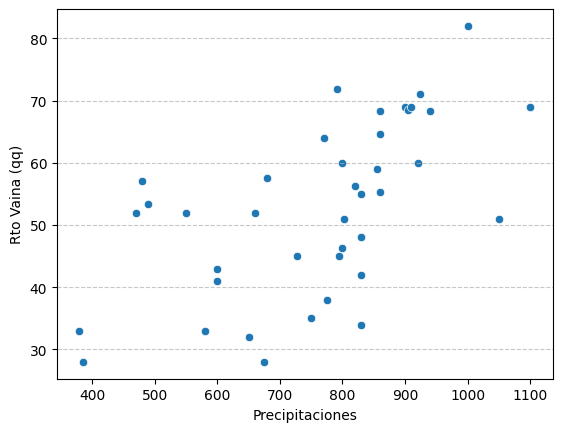

In [2]:
df['Precipitaciones'] = pd.to_numeric(df['Precipitaciones'], errors='coerce')
sns.scatterplot(data=df, x="Precipitaciones", y="Rto Vaina (qq)")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


Se puede observar que tiene una cierta tendencia lineal, por lo que es una variable que va a contribuir al modelo.

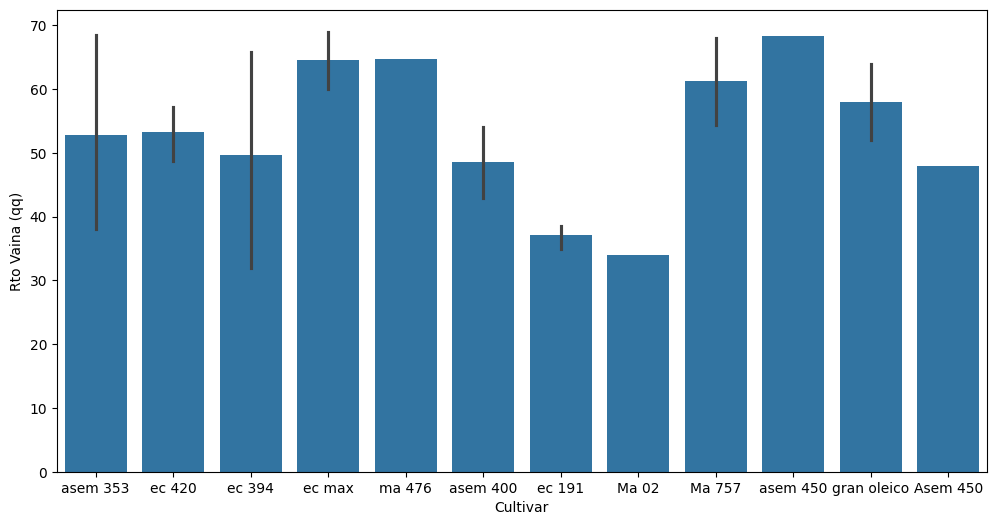

In [3]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Cultivar", y="Rto Vaina (qq)", data=df)
plt.show()

Se puede observar que hay cierto tipos de grano de maní que producen mayor rendimientos que otros

## Modelo: Random Forest

In [11]:
# ==========================================
# 1. ENTRENAMIENTO DEL MODELO BASE
# ==========================================

# 1. Eliminar espacios en blanco
df.columns = df.columns.str.strip()

# --- PASO DE LIMPIEZA CRÍTICO ---
# Convertimos las columnas de texto a MAYÚSCULAS y removemos espacios rebeldes
# Así 'directa', 'Directa' y 'DIRECTA' se transforman en una sola categoría: 'DIRECTA'
columnas_texto_a_limpiar = ['Zona', 'Tipo de Labranza', 'Cultivar', 'Antecesor']

for col in columnas_texto_a_limpiar:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().str.strip()
        # Reemplazar textos similares si es necesario (ej. simplificar labranzas directas)
        df[col] = df[col].apply(lambda x: 'DIRECTA' if 'DIRECTA' in x else x)
        df[col] = df[col].apply(lambda x: 'MINIMA' if 'MINIMA' in x else x)
        df[col] = df[col].apply(lambda x: 'CONVENCIONAL' if 'CONVENCIONAL' in x else x)

# 2. Selección de variables ampliada y limpia
col_y = 'Rto Vaina (qq)'
variables_numericas = [
    'Precipitaciones',
    'DENSIDAD DE SIEMBRA\nSemillas por metro',
    'Cuantas Aplicaciones de Fungicidas'
]
# Agregamos Cultivar (Genética) y Antecesor (Rotación) que influyen directo en el rinde
variables_categoricas = ['Zona', 'Tipo de Labranza', 'Cultivar', 'Antecesor']

columnas_interes = variables_numericas + variables_categoricas + [col_y]
df_model = df[columnas_interes].copy()

# Convertir números
for col in variables_numericas + [col_y]:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

df_model = df_model.dropna()

# 3. One-Hot Encoding limpio
df_encoded = pd.get_dummies(df_model, columns=variables_categoricas, drop_first=True)

X = df_encoded.drop(columns=[col_y])
y = df_encoded[col_y]

# 4. Ajuste del modelo con hiperparámetros optimizados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Subimos un poco la profundidad (max_depth=8) ya que combinamos categorías limpias
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_modelo', RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8))
])

pipeline.fit(X_train, y_train)

print('Modelo entrenado correctamente')

# rf_modelo = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=8)
# rf_modelo.fit(X_train, y_train)

# Evaluar
y_pred  = pipeline.predict(X_test)
# y_proba = pipeline.predict_proba(X_test)[:, 1]

# y_pred = rf_modelo.predict(X_test)
print("--- RESULTADOS RANDOM FOREST (CON DATA LIMPIA) ---")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} qq\n")

rf_modelo = pipeline.named_steps['rf_modelo']

df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia (%)': rf_modelo.feature_importances_ * 100
}).sort_values(by='Importancia (%)', ascending=False)

print("--- NUEVA IMPORTANCIA DE VARIABLES ---")
print(df_importancia.to_string(index=False))

Modelo entrenado correctamente
--- RESULTADOS RANDOM FOREST (CON DATA LIMPIA) ---
R²: 0.4442
RMSE: 8.8666 qq

--- NUEVA IMPORTANCIA DE VARIABLES ---
                               Variable  Importancia (%)
                        Precipitaciones        60.183622
DENSIDAD DE SIEMBRA\nSemillas por metro        10.918193
                        Cultivar_EC 394         8.918352
     Cuantas Aplicaciones de Fungicidas         4.115162
                   Cultivar_GRAN OLEICO         3.516257
                         Antecesor_SOJA         2.372716
                        Cultivar_EC 420         2.122449
                         Cultivar_MA 02         1.416901
                Tipo de Labranza_MINIMA         1.243344
                                Zona_SO         1.193926
                      Cultivar_ASEM 400         1.058982
                                Zona_SE         0.932861
                         Antecesor_MAÍZ         0.594949
                        Cultivar_MA 757         0.421

In [12]:
# ==========================================
# 2. FUNCIÓN SIMULADORA "WHAT-IF"
# ==========================================
def simular_rendimiento(precipitaciones, densidad, fungicidas, zona, labranza, cultivar, antecesor):
    # Crear un diccionario con el escenario, aplicando la misma limpieza de texto
    escenario = {
        'Precipitaciones': precipitaciones,
        'DENSIDAD DE SIEMBRA\nSemillas por metro': densidad,
        'Cuantas Aplicaciones de Fungicidas': fungicidas,
        'Zona': zona.upper().strip(),
        'Tipo de Labranza': labranza.upper().strip(),
        'Cultivar': cultivar.upper().strip(),
        'Antecesor': antecesor.upper().strip()
    }

    # Llevar el Tipo de Labranza a la regla del modelo
    if 'DIRECTA' in escenario['Tipo de Labranza']: escenario['Tipo de Labranza'] = 'DIRECTA'
    if 'MINIMA' in escenario['Tipo de Labranza']: escenario['Tipo de Labranza'] = 'MINIMA'
    if 'CONVENCIONAL' in escenario['Tipo de Labranza']: escenario['Tipo de Labranza'] = 'CONVENCIONAL'

    # Crear un DataFrame de una sola fila con las columnas del modelo original (todas en 0 al inicio)
    df_usuario = pd.DataFrame(0, index=[0], columns=X.columns)

    # Asignar variables numéricas
    df_usuario['Precipitaciones'] = escenario['Precipitaciones']
    df_usuario['DENSIDAD DE SIEMBRA\nSemillas por metro'] = escenario['DENSIDAD DE SIEMBRA\nSemillas por metro']
    df_usuario['Cuantas Aplicaciones de Fungicidas'] = escenario['Cuantas Aplicaciones de Fungicidas']

    # Activar las variables categóricas correspondientes (las dummies de One-Hot)
    for cat_col, valor in [('Zona', escenario['Zona']),
                           ('Tipo de Labranza', escenario['Tipo de Labranza']),
                           ('Cultivar', escenario['Cultivar']),
                           ('Antecesor', escenario['Antecesor'])]:
        nombre_col_dummy = f"{cat_col}_{valor}"
        if nombre_col_dummy in df_usuario.columns:
            df_usuario[nombre_col_dummy] = 1

    # Predecir con el Random Forest
    prediccion = pipeline.predict(df_usuario)[0]
    return prediccion

# ==========================================
# 3. CONFIGURÁ TU ESCENARIO ACÁ ABAJO
# ==========================================
# Modificá estos valores para ver cómo cambia el rinde estimado:

rinde_estimado = simular_rendimiento(
    precipitaciones = 450,       # mm totales del ciclo
    densidad = 14,               # Semillas por metro lineal
    fungicidas = 3,              # Cantidad de aplicaciones
    zona = 'SO',                 # 'SO' o 'SE'
    labranza = 'DIRECTA',        # 'DIRECTA', 'MINIMA' o 'CONVENCIONAL'
    cultivar = 'EC 394',         # Tipo de semilla (ej: 'EC 394', 'GRAN OLEICO')
    antecesor = 'SOJA'           # 'SOJA' o 'MAÍZ'
)

print("-" * 50)
print(f" RENDIMIENTO ESTIMADO POR EL MODELO: {rinde_estimado:.2f} (qq)")
print("-" * 50)

--------------------------------------------------
 RENDIMIENTO ESTIMADO POR EL MODELO: 41.71 (qq)
--------------------------------------------------


In [13]:
import os
import joblib

os.makedirs('modelo_pkl', exist_ok=True)

joblib.dump(pipeline, 'modelo_pkl/modelo_rendimiento_maní.pkl')

print('Modelo guardado en modelo_pkl/modelo_rendimiento_maní.pkl')

# Verificación: cargar y predecir de nuevo
modelo_cargado = joblib.load('modelo_pkl/modelo_rendimiento_maní.pkl')
prueba = pd.DataFrame([{
  'Precipitaciones' : 450,
  'DENSIDAD DE SIEMBRA\nSemillas por metro': 14,
  'Cuantas Aplicaciones de Fungicidas': 3,
  'Zona_SE': False,
  'Zona_SO': True,
  'Tipo de Labranza_DIRECTA': True,
  'Tipo de Labranza_MINIMA': False,
  'Cultivar_ASEM 400': False,
  'Cultivar_ASEM 450': False,
  'Cultivar_EC 191': False,
  'Cultivar_EC 394': True,
  'Cultivar_EC 420': False,
  'Cultivar_EC MAX': False,
  'Cultivar_GRAN OLEICO': False,
  'Cultivar_MA 02': False,
  'Cultivar_MA 476': False,
  'Cultivar_MA 757': False,
  'Antecesor_MAÍZ': False,
  'Antecesor_SOJA': True }])

rendimiento = modelo_cargado.predict(prueba)
print('Rendimiento: ', rendimiento, ' (qq)')


Modelo guardado en modelo_pkl/modelo_rendimiento_maní.pkl
Rendimiento:  [41.7139]  (qq)


In [ ]:
!pip install streamlit

In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import os

# 1. Configuración de la página
st.set_page_config(
    page_title="Predicción de Rendimiento de Maní",
    page_icon="🥜",
    layout="centered"
)

# 2. Cargar el modelo entrenado
MODEL_PATH = 'modelo_pkl/modelo_rendimiento_maní.pkl'

@st.cache_resource
def cargar_modelo():
    if os.path.exists(MODEL_PATH):
        return joblib.load(MODEL_PATH)
    else:
        st.error(f"No se encontró el archivo del modelo en: {MODEL_PATH}. Por favor, asegúrate de que el archivo existe.")
        return None

modelo = cargar_modelo()

# 3. Título de la aplicación
st.title("🥜 Estimador de Rendimiento de Maní")
st.write("Introduce las variables de manejo y climáticas para predecir el rendimiento estimado en quintales (qq).")

st.divider()

if modelo is not None:
    # 4. Formulario de entrada de datos
    st.header("📋 Parámetros de Entrada")

    col1, col2 = st.columns(2)

    with col1:
        precipitaciones = st.number_input("Precipitaciones (mm)", min_value=0, max_value=2000, value=450, step=10)
        densidad = st.number_input("Densidad de siembra (Semillas por metro)", min_value=1, max_value=50, value=14, step=1)
        fungicidas = st.number_input("Aplicaciones de Fungicidas", min_value=0, max_value=10, value=3, step=1)

        # Selección de Zona (Combinando en un solo dropdown)
        # Si no es SE ni SO, por defecto se asume que las variables One-Hot serán ambas False (otra zona).
        zona = st.selectbox("Zona", options=["Suroeste (SO)", "Sureste (SE)", "Otra Zona"])

    with col2:
        # Selección de Labranza
        labranza = st.selectbox("Tipo de Labranza", options=["Directa", "Mínima", "Otra / Convencional"])

        # Selección de Cultivar
        cultivares = [
            'EC 394', 'ASEM 400', 'ASEM 450', 'EC 191',
            'EC 420', 'EC MAX', 'GRAN OLEICO', 'MA 02',
            'MA 476', 'MA 757', 'Otro Cultivar'
        ]
        cultivar_seleccionado = st.selectbox("Cultivar", options=cultivares)

        # Selección de Antecesor
        antecesor = st.selectbox("Antecesor", options=["Soja", "Maíz", "Otro Antecesor"])

    # 5. Procesamiento de variables One-Hot para el DataFrame
    # Inicializamos todas las columnas del One-Hot en False de acuerdo a tu estructura original
    data_input = {
        'Precipitaciones': precipitaciones,
        'DENSIDAD DE SIEMBRA\nSemillas por metro': densidad,
        'Cuantas Aplicaciones de Fungicidas': fungicidas,
        'Zona_SE': zona == "Sureste (SE)",
        'Zona_SO': zona == "Suroeste (SO)",
        'Tipo de Labranza_DIRECTA': labranza == "Directa",
        'Tipo de Labranza_MINIMA': labranza == "Mínima",
        'Cultivar_ASEM 400': cultivar_seleccionado == 'ASEM 400',
        'Cultivar_ASEM 450': cultivar_seleccionado == 'ASEM 450',
        'Cultivar_EC 191': cultivar_seleccionado == 'EC 191',
        'Cultivar_EC 394': cultivar_seleccionado == 'EC 394',
        'Cultivar_EC 420': cultivar_seleccionado == 'EC 420',
        'Cultivar_EC MAX': cultivar_seleccionado == 'EC MAX',
        'Cultivar_GRAN OLEICO': cultivar_seleccionado == 'GRAN OLEICO',
        'Cultivar_MA 02': cultivar_seleccionado == 'MA 02',
        'Cultivar_MA 476': cultivar_seleccionado == 'MA 476',
        'Cultivar_MA 757': cultivar_seleccionado == 'MA 757',
        'Antecesor_MAÍZ': antecesor == "Maíz",
        'Antecesor_SOJA': antecesor == "Soja"
    }

    # Crear el DataFrame con la misma estructura que espera el pipeline
    df_prueba = pd.DataFrame([data_input])

    st.divider()

    # 6. Botón de Predicción y Resultado
    if st.button("🔮 Calcular Rendimiento Estimado", type="primary"):
        with st.spinner("Procesando datos..."):
            try:
                # Realizar la predicción
                rendimiento = modelo.predict(df_prueba)

                # Mostrar el resultado destacado
                st.success("### ¡Predicción Calculada con Éxito!")
                st.metric(
                    label="Rendimiento Estimado",
                    value=f"{rendimiento[0]:.2f} qq"
                )
            except Exception as e:
                st.error(f"Ocurrió un error al realizar la predicción: {e}")

Writing app.py


In [16]:
!streamlit run app.py &>/dev/null &

In [17]:
!ssh -o StrictHostKeyChecking=no -R 80:localhost:8501 serveo.net

Forwarding HTTP traffic from https://39013c6f9d60739a-34-16-236-205.serveousercontent.com
Tip (1): Create an account to reserve names. Pro removes the warning page: https://console.serveo.net/settings?n=1&src=ssh_nudge&v=A
